# Import and Install libraries

Install all important libraries using !pip install
All libraries needed to install 
1. tqdm
2. keras
3. tensorflow

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Input, LSTM, Bidirectional, GlobalMaxPool1D, Embedding, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

In [2]:
# Load the data
data = pd.read_csv('train.csv')

In [3]:
data

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [4]:
# Select the features and target
X = data['comment_text'].values
y = data[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values

In [5]:
# Tokenization
max_features = 20000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X)
X = tokenizer.texts_to_sequences(X)

In [6]:
# Padding
maxlen = 100
X = pad_sequences(X, maxlen=maxlen)

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
#glove embedding
GLOVE_6B_50D_PATH = "glove.6B.50d.txt"
index_len = len(tokenizer.word_index)
glove = {}
dimension = 50
glove_matrix = np.zeros((index_len+1,dimension))
glove_path = open(GLOVE_6B_50D_PATH)
for line in tqdm(glove_path):
    line_arr = line.split()
    word = line_arr[0]
    glove[word] = np.asarray(line_arr[1:], dtype='float32')
glove_path.close()
for word, idx in tqdm(tokenizer.word_index.items()):
    if word in glove: glove_matrix[idx] = glove[word]

400000it [00:03, 127874.10it/s]
100%|██████████████████████████████| 210337/210337 [00:00<00:00, 1408737.00it/s]


In [9]:
#normalization 
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

porter = PorterStemmer()
sw = set(stopwords.words('english'))
sw.update(['.', "'", '(', ')', '[', ']', '{', '}', ',', '"', ':', ';'])

def vectorize(sentence):
    words = str(sentence).lower()  
    tokenized = word_tokenize(words)
    updated_tokens = []
    final_tokens = []
    
    for word in tokenized:
        if not word in sw and word.isalpha(): 
            updated_tokens.append(word)
            
    for token in updated_tokens:
        try:
            final_tokens.append(glove[token.lower()])  
        except:
            continue  
    
    final_tokens = np.array(final_tokens)
    total =  final_tokens.sum(axis=0)
    data_type = type(total)
    
    if data_type != np.ndarray: 
        return np.zeros(50)  
    
    denom = np.sqrt((total ** 2).sum())
    return total / denom

[nltk_data] Downloading package punkt to /Users/s1mankhan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
xg_train = [vectorize(sentence) for sentence in tqdm(X_train)]
xg_test = [vectorize(sentence) for sentence in tqdm(X_test)]

100%|███████████████████████████████████| 39893/39893 [00:12<00:00, 3078.70it/s]


# Long Short term memory

In [13]:
# Define the model
max_features = 20000
embedding_size = 128
lstm_units = 64

model = Sequential()
model.add(Embedding(max_features, embedding_size))
model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))
model.add(GlobalMaxPool1D())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(6, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
batch_size = 32
epochs = 3
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)
print("Test Accuracy: %.2f%%" % (accuracy * 100.0))

Epoch 1/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 288s 85ms/step - accuracy: 0.8624 - loss: 0.0933 - val_accuracy: 0.9941 - val_loss: 0.0518
Epoch 2/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 325s 96ms/step - accuracy: 0.9758 - loss: 0.0451 - val_accuracy: 0.9936 - val_loss: 0.0523
Epoch 3/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 355s 105ms/step - accuracy: 0.9701 - loss: 0.0384 - val_accuracy: 0.9941 - val_loss: 0.0521
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step
Test Accuracy: 92.06%


# F1 score

In [14]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer


# Binarize y_pred
threshold = 0.5
y_pred_binarized = (y_pred > threshold).astype(int)

# Flatten the arrays
mlb = MultiLabelBinarizer()
y_test_flat = mlb.fit_transform(y_test)
y_pred_flat = mlb.transform(y_pred_binarized)

# Calculate F1-score
f1 = f1_score(y_test_flat, y_pred_flat, average='macro')

print("F1-score:", f1)


F1-score: 0.8981700025149172


# Probability Callibration curve

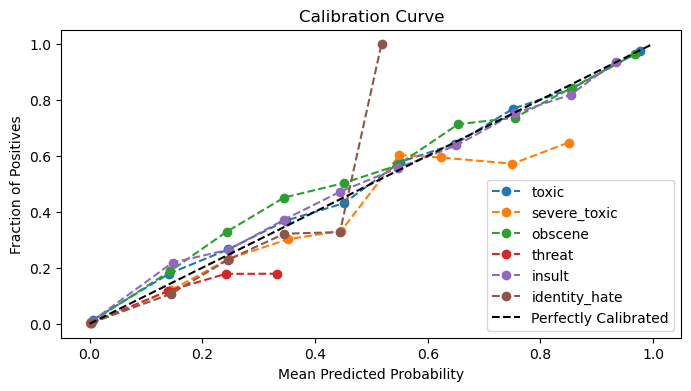

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels

def plot_calibration_curve(y_test, y_pred, class_names=None, n_bins=10, strategy='uniform'):
    # Get unique classes from y_test_sample
    classes = unique_labels(y_test)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8, 4))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred[:, i], n_bins=n_bins, strategy=strategy)
        label = f'Class {classes[i]}' if class_names is None else class_names[i]
        plt.plot(prob_pred, prob_true, marker='o', label=label, linestyle='--')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend(loc='lower right')
    plt.show()

# Class names corresponding to the classes in y_test_sample
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Specify the number of bins
n_bins = 10

plot_calibration_curve(y_test, y_pred, class_names=class_names, n_bins=n_bins)

# Confusion matrix

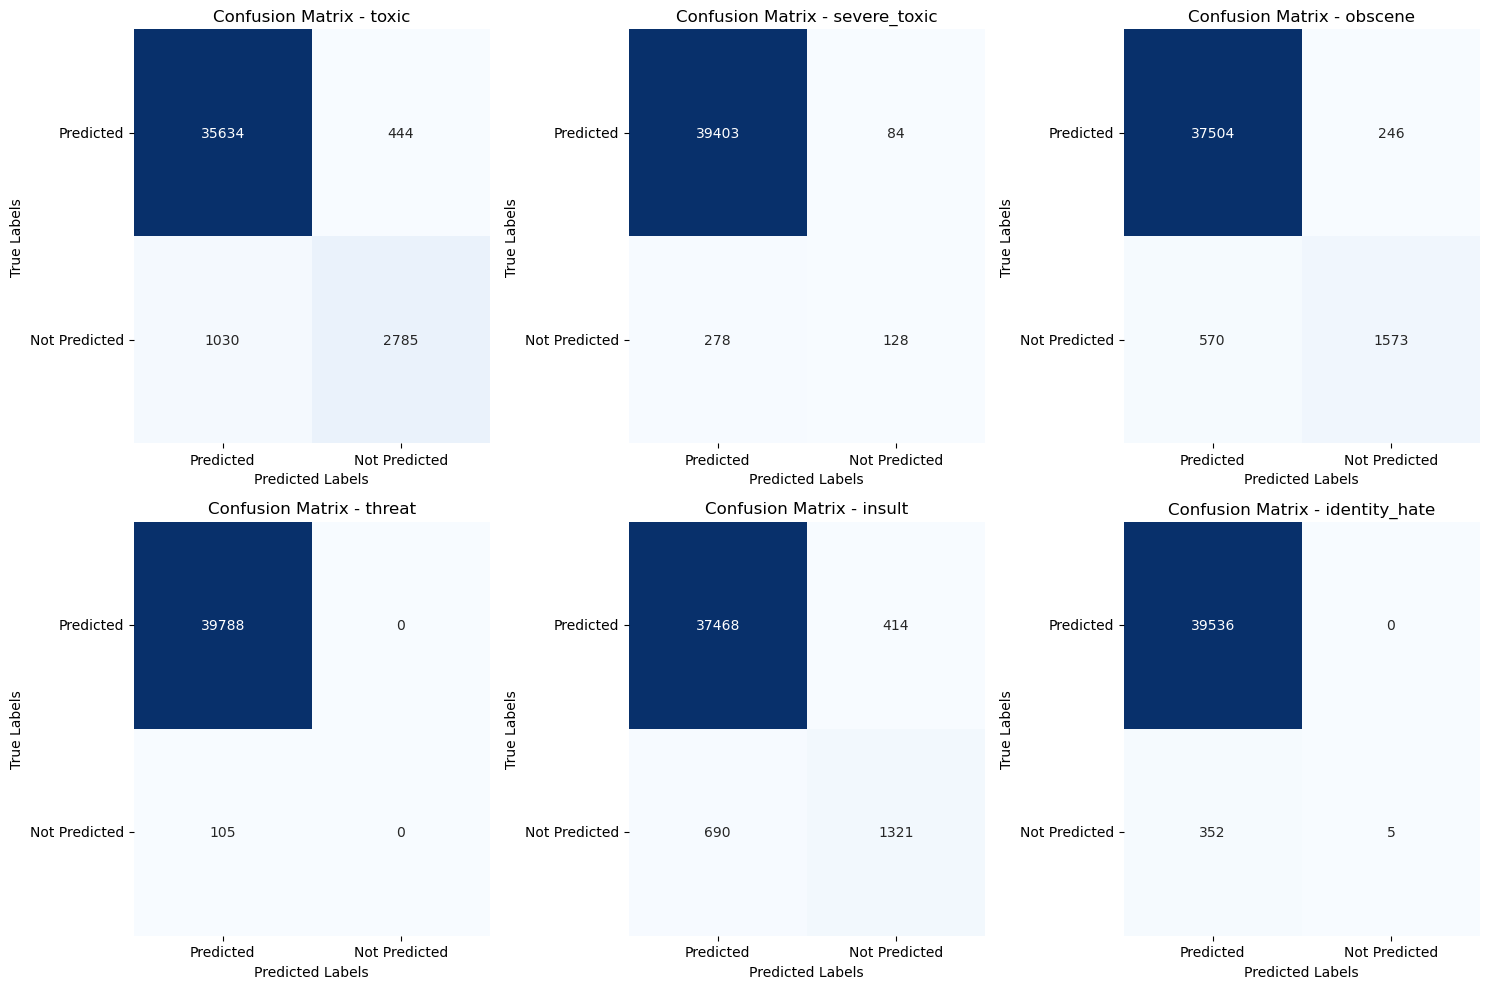

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

# Define class names
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_pred_binary = (y_pred > 0.5).astype(int)

# Compute the confusion matrix for each label
cm = multilabel_confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrices for each label
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted', 'Not Predicted'], yticklabels=['Predicted', 'Not Predicted'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {class_names[i]}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()

# Convolutional Neural Network

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import accuracy_score

# Define the model
max_features = 20000
embedding_size = 128
num_filters = 64
kernel_size = 3

model = Sequential()
model.add(Embedding(max_features, embedding_size))
model.add(Conv1D(num_filters, kernel_size, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
batch_size = 32
epochs = 3
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

# Evaluate the model
y_pred_cnn = model.predict(X_test)
y_pred_binary = (y_pred_cnn > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)
print("Test Accuracy: %.2f%%" % (accuracy * 100.0))


Epoch 1/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.8359 - loss: 0.0993 - val_accuracy: 0.9941 - val_loss: 0.0539
Epoch 2/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.9854 - loss: 0.0455 - val_accuracy: 0.9941 - val_loss: 0.0518
Epoch 3/3
3366/3366 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.9680 - loss: 0.0363 - val_accuracy: 0.9940 - val_loss: 0.0544
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test Accuracy: 91.77%


# F1 score

In [18]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer


# Binarize y_pred
threshold = 0.5
y_pred_binarized = (y_pred_cnn > threshold).astype(int)

# Flatten the arrays
mlb = MultiLabelBinarizer()
y_test_flat = mlb.fit_transform(y_test)
y_pred_flat = mlb.transform(y_pred_binarized)

# Calculate F1-score
f1 = f1_score(y_test_flat, y_pred_flat, average='macro')

print("F1-score:", f1)


F1-score: 0.8904926483372724


# Probability callibration curve

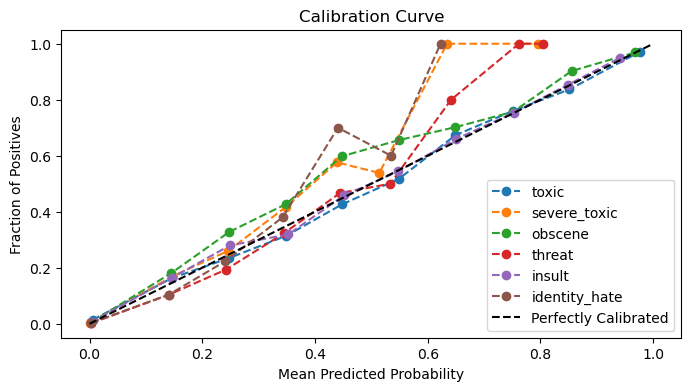

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels

def plot_calibration_curve(y_test, y_pred_cnn, class_names=None, n_bins=10, strategy='uniform'):
    # Get unique classes from y_test_sample
    classes = unique_labels(y_test)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8, 4))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred_cnn[:, i], n_bins=n_bins, strategy=strategy)
        label = f'Class {classes[i]}' if class_names is None else class_names[i]
        plt.plot(prob_pred, prob_true, marker='o', label=label, linestyle='--')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend(loc='lower right')
    plt.show()

# Class names corresponding to the classes in y_test_sample
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Specify the number of bins
n_bins = 10

plot_calibration_curve(y_test, y_pred_cnn, class_names=class_names, n_bins=n_bins)


# Confusion matrix

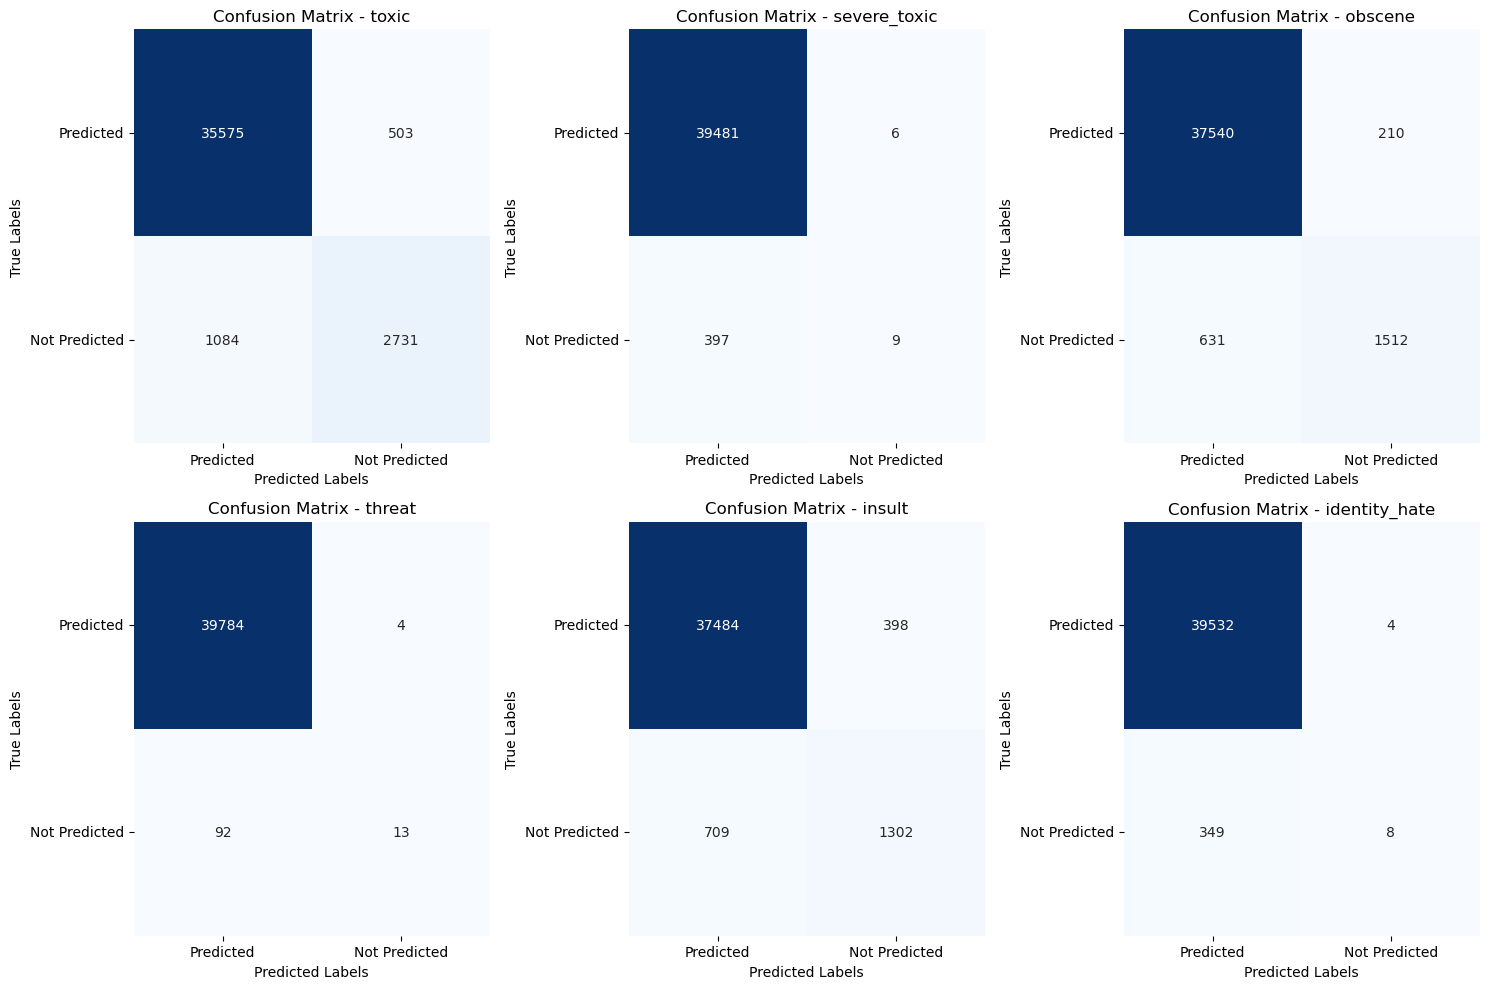

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

# Define class names
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_pred_binary = (y_pred_cnn > 0.5).astype(int)

# Compute the confusion matrix for each label
cm = multilabel_confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrices for each label
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted', 'Not Predicted'], yticklabels=['Predicted', 'Not Predicted'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {class_names[i]}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()
